# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## Environment Setup & Tools
In this section, we initialize the workspace by importing core libraries.

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display_image(image, title="Image View"):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


def get_rectified_view(image, src_pts, w, h):
    """
    Transforms the perspective of a 4-point selection into a flat rectangle.
    """
    dst_pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    return cv2.warpPerspective(image, M, (w, h))

print("Setup Complete. Tools are ready!")

Setup Complete. Tools are ready!


## Perspective Transformation
To accurately analyze the board, we must correct the perspective distortion caused by the camera angle. 

Starting automation on 4 images...


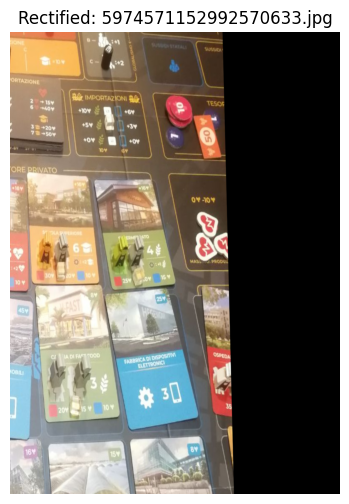

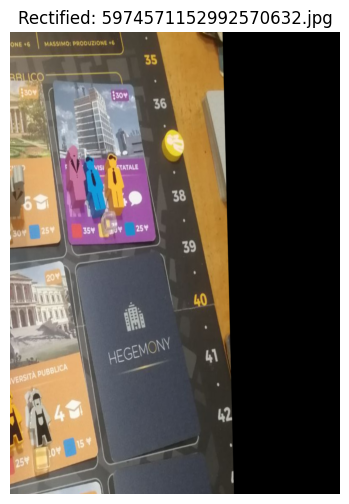

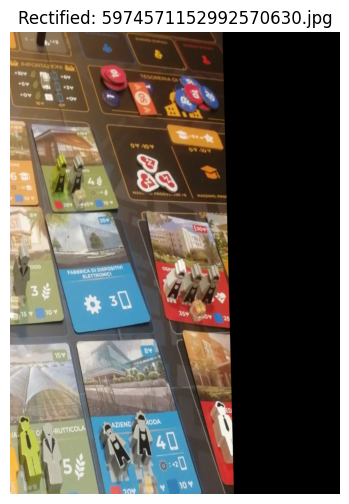

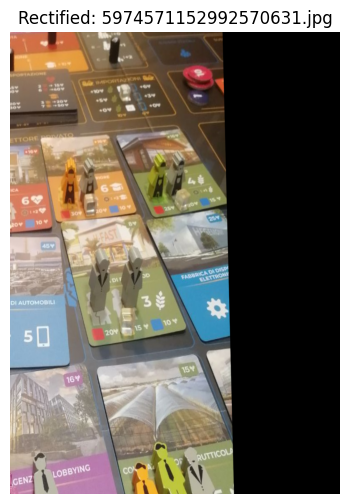

In [6]:
import os

folder_path = '../imgs/'
# Get all images from the folder
img_list = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Define your board corners ONCE 
# Order: Top-Left, Top-Right, Bottom-Right, Bottom-Left
src_pts = np.float32([
    [452, 128],   # TL 
    [1240, 150],  # TR
    [1210, 890],  # BR
    [430, 870]    # BL
])

# Output
out_w, out_h = 1000, 1400

print(f"Starting automation on {len(img_list)} images...")

for file_name in img_list:
    # Load each image
    img = cv2.imread(os.path.join(folder_path, file_name))
    
    if img is not None:
        # Apply the transformation 
        rectified = get_rectified_view(img, src_pts, out_w, out_h)
        
        # Show or Save the result
        display_image(rectified, title=f"Rectified: {file_name}")    
    else:
        print(f"Skipping {file_name}: File error.")

## Color Segmentation
We use the **HSV color space** because it separates chromaticity (Hue) from luminosity (Value), making our detection more stable under different lighting conditions.

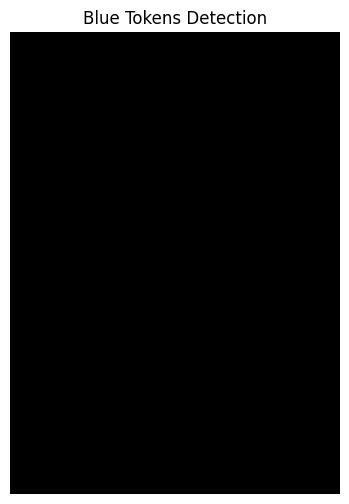

In [3]:
# 1. Convert to HSV
hsv_board = cv2.cvtColor(rectified_img, cv2.COLOR_BGR2HSV)

# Let's target BLUE tokens first
lower_blue = np.array([100, 150, 50])
upper_blue = np.array([140, 255, 255])

# 3. Create Mask
blue_mask = cv2.inRange(hsv_board, lower_blue, upper_blue)

# 4. Apply Mask 
blue_detected = cv2.bitwise_and(rectified_img, rectified_img, mask=blue_mask)

# 5. Display 
display_image(blue_detected, title="Blue Tokens Detection")